In [82]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({
    "font.size": 16,        # base font
    "axes.titlesize": 20,   # title
    "axes.labelsize": 18,   # x/y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
    "legend.fontsize": 16,  # legend
})

In [83]:
format_factor = 2.0

def Lambda(x):
    return format_factor * np.exp(-x)

def H(x):
    x = np.asarray(x)
    return format_factor * np.where(x >= -1, np.exp(-(x + 1)), -x)

def F(x):
    x = np.asarray(x)
    return np.where(x >= -1, x + 1, 0.0)

In [84]:
Q = 10
gamma = 0.1
sigma = 1.0
T = 10

V(0,0) = 13.179559061326222
Check terminal condition: V(T,0) = 0.0


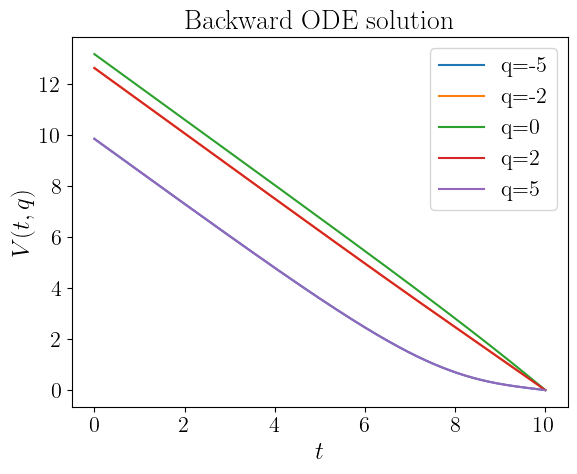

In [85]:
# Inventory grid q in {-Q, ..., Q}
qs = np.arange(-Q, Q + 1, dtype=int)
nqs = len(qs)


# Inventory-penalization term
def running_term(t, q):
    return 0.5 * gamma * sigma**2 * q**2


# RHS of the ODE system
def rhs(t, v):
    dv = np.zeros_like(v)

    for i, q in enumerate(qs):
        val = running_term(t, q)
        if q > -Q:
            val -= H(v[i] - v[i - 1])
        if q < Q:
            val -= H(v[i] - v[i + 1])

        dv[i] = val
    return dv


# Time grid for backward solve (must be decreasing because we solve from T to 0)
t_eval = np.linspace(T, 0.0, 2000)

# Terminal condition vector (v(T,q) = 0 for all q)
vT = np.zeros(nqs)

# Solve backward ODE
sol = solve_ivp(
    fun=rhs,
    t_span=(T, 0.0),
    y0=vT,
    t_eval=t_eval,
)

if not sol.success:
    raise RuntimeError(f"ODE solve failed: {sol.message}")

# Build interpolation helper v_of_t_q(t, q)
ts = sol.t          # descending
vs = sol.y          # shape (nqs, n_t)

# q_to_idx = {q: i for i, q in enumerate(qs)}

q_to_idx = lambda q: q+Q  # since qs = [-Q, ..., Q], we can just shift by Q to get the index

def v_of_t_q(t, q):
    i = q_to_idx(q)
    return np.interp(t, ts[::-1], vs[i, ::-1])


# Checks
print("V(0,0) =", v_of_t_q(0.0, 0))
print("Check terminal condition: V(T,0) =", v_of_t_q(T, 0))


# Plot v(t,q) for a few q values
for q in [-5, -2, 0, 2, 5]:
    i = q_to_idx(q)
    plt.plot(sol.t[::-1], sol.y[i, ::-1], label=f"q={q}")

plt.xlabel(r"$t$")
plt.ylabel(r"$V(t,q)$")
plt.title("Backward ODE solution")
plt.legend()
plt.show()

In [86]:
q0 = 0
S0 = 0.0
x0 = 0.0

dt = 0.01
n_steps = int(T / dt)
time_grid = np.linspace(0.0, T, n_steps + 1)

# Choose how many paths to simulate for the check n_paths = 20000
n_paths = 20000
seed = 12345

# Precompute V(t,q) on the simulation grid
# V_grid shape = (n_steps + 1, n), with time increasing from 0 to T
V_grid = np.empty((n_steps + 1, nqs))
for j, q in enumerate(qs):
    V_grid[:, j] = np.interp(time_grid, ts[::-1], vs[j, ::-1])

# Precompute quote tables
delta_b_table = np.full((n_steps + 1, nqs), np.nan)
delta_a_table = np.full((n_steps + 1, nqs), np.nan)

for q in qs:
    j = q_to_idx(q)
    if q < Q:
        delta_b_table[:, j] = F(V_grid[:, j] - V_grid[:, j + 1])
    if q > -Q:
        delta_a_table[:, j] = F(V_grid[:, j] - V_grid[:, j - 1])


def mc_value_for_q0(q0, n_paths=20000, seed=12345, verbose=False, store_quotes=False):

    rng = np.random.default_rng(seed)
    
    # Simulate optimal strategy and estimate the value
    S = np.full(n_paths, S0, dtype=np.float64)      # asset price
    q = np.full(n_paths, q0, dtype=np.int32)        # inventory
    x = np.full(n_paths, x0, dtype=np.float64)      # cash
    PnL = np.zeros(n_paths, dtype=np.float64)       # PnL
    da = np.zeros(n_steps, dtype=np.float64)        # ask quote
    db = np.zeros(n_steps, dtype=np.float64)        # bid quote
    q_path = np.zeros(n_steps+1, dtype=np.int32)  # store inventory paths for analysis
    q_path[0] = q0
    asset_price_path = np.zeros(n_steps + 1, dtype=np.float64)  # store asset price paths for analysis
    asset_price_path[0] = S0

    # running approximation of integral \int_0^T q_t^2 dt
    inventory_penalty_integral = np.zeros(n_paths, dtype=np.float64)


    for k in range(n_steps):
        # accumulate \int q_t^2 dt using left-point rule
        inventory_penalty_integral += q**2 * dt

        # get index of current inventory level in precomputed tables
        q_idx = q_to_idx(q)

        # get optimal quotes from tables
        delta_b = delta_b_table[k, q_idx]
        delta_a = delta_a_table[k, q_idx]
        
        # compute Poisson intensities for each path
        lambda_b = np.where(q < Q, Lambda(delta_b), 0.0)
        lambda_a = np.where(q > -Q, Lambda(delta_a), 0.0)

        # Poisson draws, capped at 1 per side
        bid_exec = np.minimum(rng.poisson(lambda_b * dt), 1)
        ask_exec = np.minimum(rng.poisson(lambda_a * dt), 1)
        
        # check that bid and ask executions don't happen simultaneously (which would be unrealistic)
        both_exec = (bid_exec == 1) & (ask_exec == 1)
        if np.any(both_exec):
            # randomly keep only one of the two executions for each affected path
            keep_bid = rng.random(size=np.sum(both_exec)) < 0.5
            bid_exec[both_exec] = keep_bid.astype(int)
            ask_exec[both_exec] = (~keep_bid).astype(int)

        # update cash / inventory
        x -= bid_exec * (S - np.nan_to_num(delta_b, nan=0.0))
        q += bid_exec

        x += ask_exec * (S + np.nan_to_num(delta_a, nan=0.0))
        q -= ask_exec

        q = np.clip(q, -Q, Q)

        # mid-price evolution
        S += sigma * np.sqrt(dt) * rng.normal(size=n_paths)
        
        # store quotes of the first path for analysis
        if store_quotes:
            q_path[k + 1] = q[0]
            asset_price_path[k + 1] = S[0]
            da[k] = delta_a[0]
            db[k] = delta_b[0]

    # terminal payoff path by path
    payoff_paths = x + q * S - 0.5 * gamma * sigma**2 * inventory_penalty_integral
    PnL = x + q*S
    # compute mean and standard error of the Monte Carlo estimate for each q0
    mc_mean = np.mean(payoff_paths, axis=0)
    mc_std = np.std(payoff_paths, ddof=1)
    mc_se = mc_std / np.sqrt(n_paths)

    v_theory = V_grid[0, q_to_idx(q0)]

    if verbose:
        print("Number of paths simulated      =", n_paths)
        print("Theoretical value V(0,q0)      =", v_theory)
        print("Monte Carlo estimate           =", mc_mean)
        print("Monte Carlo std                =", mc_std)
        print("Monte Carlo standard error     =", mc_se)
        print("Absolute error                 =", abs(mc_mean - v_theory))
        print("95% confidence interval        = [{:.6f}, {:.6f}]".format(
            mc_mean - 1.96 * mc_se, mc_mean + 1.96 * mc_se
        ))
        print("Is V(0,q0) in the 95% CI?      =", (mc_mean - 1.96 * mc_se <= v_theory <= mc_mean + 1.96 * mc_se))
        
    return {
        "q0": q0,
        "q_path": q_path,
        "S": asset_price_path,
        "Payoff_paths": payoff_paths,
        "PnL": PnL,
        "da": da,
        "db": db,
        "V_theory": v_theory,
        "MC_mean": mc_mean,
        "MC_std": mc_std,
        "MC_se": mc_se,
        "abs_error": abs(mc_mean - v_theory),
        "ci_low": mc_mean - 1.96 * mc_se,
        "ci_high": mc_mean + 1.96 * mc_se,
        "covered": (mc_mean - 1.96 * mc_se <= v_theory <= mc_mean + 1.96 * mc_se),
    }
        
res = mc_value_for_q0(q0, n_paths=20000, seed=12345, verbose=True)

Number of paths simulated      = 20000
Theoretical value V(0,q0)      = 13.179559061326222
Monte Carlo estimate           = 13.033372508437354
Monte Carlo std                = 5.592571034139503
Monte Carlo standard error     = 0.039545449025075056
Absolute error                 = 0.14618655288886728
95% confidence interval        = [12.955863, 13.110882]
Is V(0,q0) in the 95% CI?      = False


In [87]:
q0s = [q0] # initial inventory levels to test
big_result = mc_value_for_q0(q0=q0, n_paths=1_000_000)

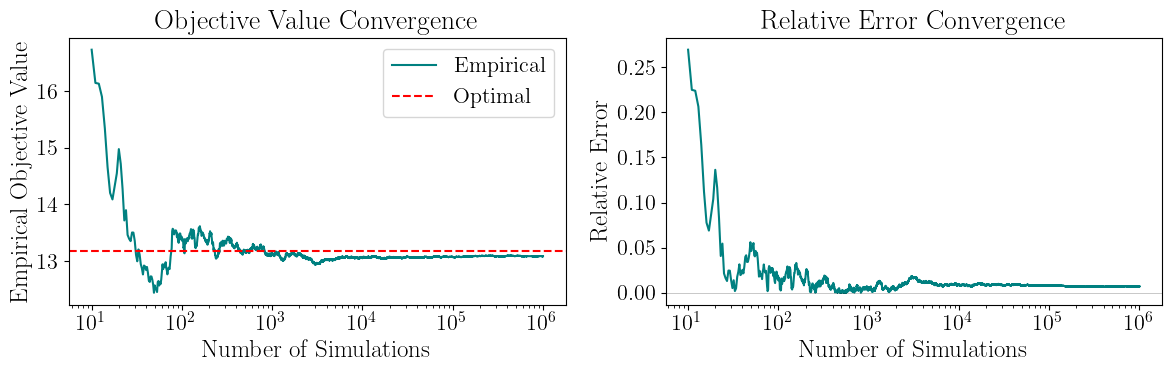

In [90]:
payoffs = big_result["Payoff_paths"]
true_value = big_result["V_theory"]
avgs = np.cumsum(payoffs) / np.arange(1, len(payoffs) + 1)
rel_error = np.abs(avgs - true_value) / np.abs(true_value)
FROM = 10

plt.subplots(1, 2, figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.arange(FROM, payoffs.shape[0] + 1), avgs[FROM-1:], color="teal", label='Empirical')
plt.axhline(v_of_t_q(0,0), color="r", linestyle='--', label='Optimal')
plt.xscale('log')
plt.title('Objective Value Convergence')
plt.xlabel('Number of Simulations')
plt.ylabel('Empirical Objective Value')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.arange(FROM, payoffs.shape[0] + 1), rel_error[FROM-1:], color="teal")
plt.axhline(0, linewidth=.5, color="black", alpha=0.3)
plt.xscale('log')
plt.title('Relative Error Convergence')
plt.xlabel('Number of Simulations')
plt.ylabel('Relative Error')

plt.tight_layout()
plt.savefig("Plots/ct_average_value_convergence.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

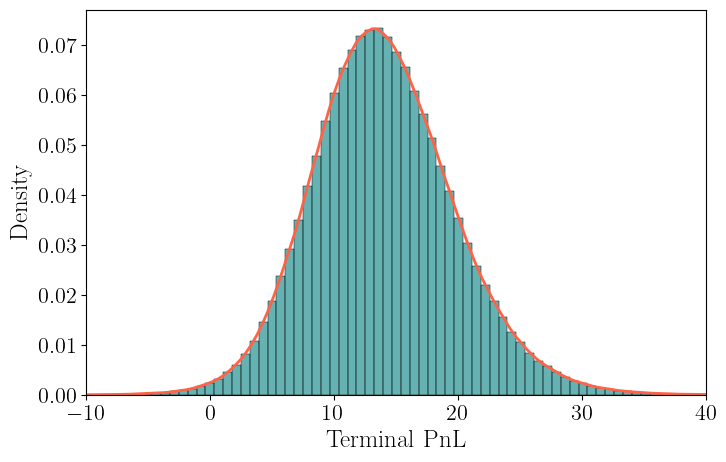

In [238]:
PnL = big_result["PnL"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    PnL,
    bins=120,
    stat="density",
    color="teal",
    alpha=0.6,   # makes it nicer visually
    ax=ax
)

# KDE line (separate, full control)
sns.kdeplot(
    PnL,
    color="tomato",
    linewidth=2,
    ax=ax
)

ax.set_xlabel("Terminal PnL")
ax.set_ylabel("Density")
ax.set_xlim(-10, 40)

plt.savefig("Plots/ct_pnl_distribution.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/hr/wt83vx857tb5stw6bpqw6ss00000gn/T/ipykernel_8486/3707024100.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


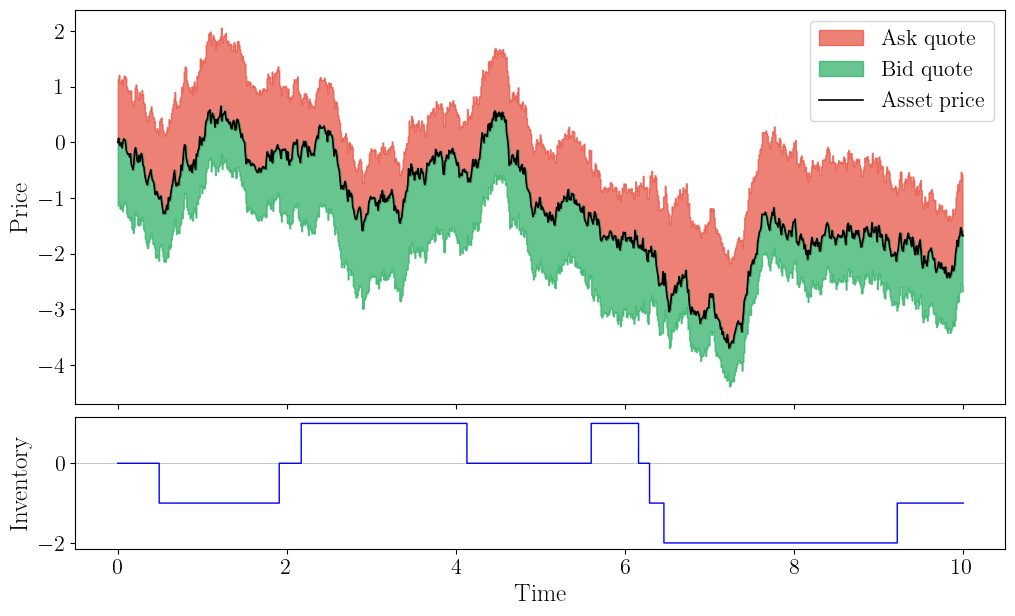

In [92]:
path_for_quotes = mc_value_for_q0(q0=0, n_paths=1, seed=12, store_quotes=True)
q_path = path_for_quotes["q_path"]
asset_price_path = path_for_quotes["S"]
da = path_for_quotes["da"]
db = path_for_quotes["db"]
ASK_COLOR = "#E74C3C"
BID_COLOR = "#27AE60"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                sharex=True,
                                gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
                                )

# --- Top: price + quote flags ---
# ax1.vlines(time_grid[:-1], asset_price_path[:-1], asset_price_path[:-1] + da, linewidth=1.5, alpha=0.7, color=ASK_COLOR, label="Ask quote")
# ax1.vlines(time_grid[:-1], asset_price_path[:-1] - db, asset_price_path[:-1], linewidth=1.5, alpha=0.7, color=BID_COLOR, label="Bid quote")
ax1.fill_between(time_grid[:-1], asset_price_path[:-1], asset_price_path[:-1] + da, step="post", alpha=0.7, color=ASK_COLOR, label="Ask quote")
ax1.fill_between(time_grid[:-1], asset_price_path[:-1] - db, asset_price_path[:-1], step="post", alpha=0.7, color=BID_COLOR, label="Bid quote")
ax1.plot(time_grid, asset_price_path, linewidth=1.2, label="Asset price", color="black")
ax1.set_ylabel("Price")
# ax1.set_title("Optimal quotes as flags on the asset price")
ax1.legend(loc="best")

# --- Bottom: inventory ---
ax2.step(time_grid, q_path, where="post", linewidth=1, color="blue", label=r"Inventory $q$")
ax2.axhline(0, linewidth=.5, color="black", alpha=0.3)
ax2.set_ylabel("Inventory")
ax2.set_xlabel("Time")

fig.tight_layout()
plt.savefig("Plots/ct_optimal_quotes.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

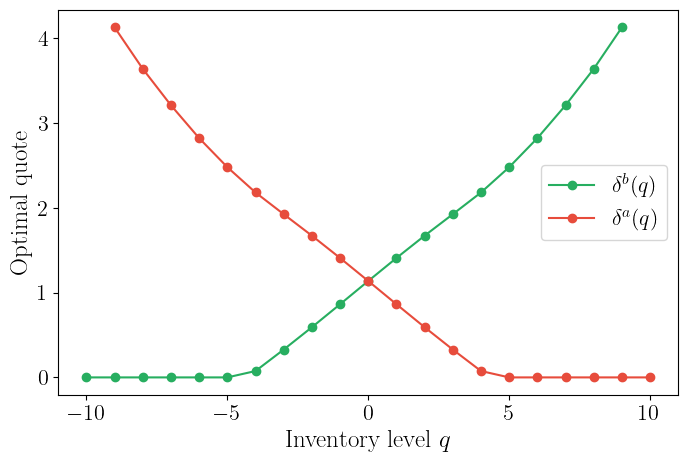

In [ ]:
# see how optimal quotes evolve with inventory level at t=0
q_range = np.arange(-Q, Q + 1, dtype=int)
delta_b_0 = delta_b_table[0, q_to_idx(q_range)]
delta_a_0 = delta_a_table[0, q_to_idx(q_range)]
plt.figure(figsize=(8, 5))
plt.plot(q_range, delta_b_0, marker="o", color=BID_COLOR, label=r"$\delta^b(q)$")
plt.plot(q_range, delta_a_0, marker="o", color=ASK_COLOR, label=r"$\delta^a(q)$")
plt.xlabel("Inventory level $q$")
plt.ylabel("Optimal quote")
plt.legend()
plt.xticks(q_range[::5])
plt.savefig("Plots/ct_optimal_quotes_vs_inventory.pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()

### Efficient Frontier

In [ ]:
def solve_V_and_quote_tables(gamma, Q, T, sigma, qs, n_steps, time_grid, H, F, method="BDF"):
    """
    Solve the backward ODE for a given gamma, then build:
      - V_grid[t_idx, q_idx]
      - delta_b_table[t_idx, q_idx]
      - delta_a_table[t_idx, q_idx]

    Returns a dict with all needed objects.
    """
    nqs = len(qs)
    q_to_idx = lambda q: q + Q

    # inventory penalization term
    def running_term(t, q):
        return 0.5 * gamma * sigma**2 * q**2

    # ODE for the value function
    def rhs(t, v):
        dv = np.zeros_like(v)
        for i, q in enumerate(qs):
            val = running_term(t, q)
            if q > -Q:
                val -= H(v[i] - v[i - 1])
            if q < Q:
                val -= H(v[i] - v[i + 1])
            dv[i] = val
        return dv

    # backward time grid for ODE solve
    t_eval_backward = np.linspace(T, 0.0, 2000)
    vT = np.zeros(nqs)

    # solve ODE
    sol = solve_ivp(
        fun=rhs,
        t_span=(T, 0.0),
        y0=vT,
        t_eval=t_eval_backward,
        method=method,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solve failed for gamma={gamma}: {sol.message}")

    ts = sol.t
    vs = sol.y

    # interpolate to get a continuous function
    V_grid = np.empty((n_steps + 1, nqs))
    for j, q in enumerate(qs):
        V_grid[:, j] = np.interp(time_grid, ts[::-1], vs[j, ::-1])

    # compute quote tables
    delta_b_table = np.full((n_steps + 1, nqs), np.nan)
    delta_a_table = np.full((n_steps + 1, nqs), np.nan)

    for q in qs:
        j = q_to_idx(q)
        if q < Q:
            delta_b_table[:, j] = F(V_grid[:, j] - V_grid[:, j + 1])
        if q > -Q:
            delta_a_table[:, j] = F(V_grid[:, j] - V_grid[:, j - 1])

    return {
        "gamma": gamma,
        "sol": sol,
        "V_grid": V_grid,
        "delta_b_table": delta_b_table,
        "delta_a_table": delta_a_table,
    }
    
    
def simulate_terminal_pnl_for_gamma(
    gamma,
    V_grid,
    delta_b_table,
    delta_a_table,
    q0,
    Q,
    T,
    sigma,
    S0,
    x0,
    dt,
    n_paths,
    Lambda,
    seed=12345,
):
    """
    Simulate the optimal strategy associated with one gamma and return
    terminal PnL statistics.
    """
    rng = np.random.default_rng(seed)

    n_steps = int(T / dt)
    q_to_idx = lambda q: q + Q

    S = np.full(n_paths, S0, dtype=np.float64)
    q = np.full(n_paths, q0, dtype=np.int32)
    x = np.full(n_paths, x0, dtype=np.float64)

    inventory_penalty_integral = np.zeros(n_paths, dtype=np.float64)

    sqrt_dt = np.sqrt(dt)

    for k in range(n_steps):
        inventory_penalty_integral += q**2 * dt

        q_idx = q_to_idx(q)

        delta_b = delta_b_table[k, q_idx]
        delta_a = delta_a_table[k, q_idx]

        lambda_b = np.where(q < Q, Lambda(delta_b), 0.0)
        lambda_a = np.where(q > -Q, Lambda(delta_a), 0.0)

        bid_exec = np.minimum(rng.poisson(lambda_b * dt), 1)
        ask_exec = np.minimum(rng.poisson(lambda_a * dt), 1)

        # forbid simultaneous executions
        both_exec = (bid_exec == 1) & (ask_exec == 1)
        if np.any(both_exec):
            keep_bid = rng.random(size=np.sum(both_exec)) < 0.5
            bid_exec[both_exec] = keep_bid.astype(int)
            ask_exec[both_exec] = (~keep_bid).astype(int)

        x -= bid_exec * (S - np.nan_to_num(delta_b, nan=0.0))
        q += bid_exec

        x += ask_exec * (S + np.nan_to_num(delta_a, nan=0.0))
        q -= ask_exec

        q = np.clip(q, -Q, Q)

        S += sigma * sqrt_dt * rng.normal(size=n_paths)

    terminal_pnl = x + q * S
    terminal_payoff = terminal_pnl - 0.5 * gamma * sigma**2 * inventory_penalty_integral

    return {
        "terminal_pnl_paths": terminal_pnl,
        "terminal_payoff_paths": terminal_payoff,
        "mean_pnl": terminal_pnl.mean(),
        "var_pnl": terminal_pnl.var(),
        "std_pnl": terminal_pnl.std(ddof=1),
        "mean_payoff": terminal_payoff.mean(),
        "var_payoff": terminal_payoff.var(),
    }
    
    
def pnl_variance_vs_gamma_continuous(
    gammas,
    Q,
    T,
    sigma,
    S0,
    x0=0.0,
    q0=0,
    dt=0.01,
    n_paths=20000,
    Lambda=None,
    H=None,
    F=None,
    ode_method="BDF",
    base_seed=12345,
    verbose=True,
):
    """
    For each gamma:
      1. solve the backward ODE,
      2. build optimal quote tables,
      3. simulate the associated strategy,
      4. return terminal PnL mean/variance.

    Returns
    -------
    mean_pnl : np.ndarray
    var_pnl  : np.ndarray
    mean_payoff : np.ndarray
    frontier_details : list of dict
    """
    qs = np.arange(-Q, Q + 1, dtype=int)
    n_steps = int(T / dt)
    time_grid = np.linspace(0.0, T, n_steps + 1)

    mean_pnl = np.empty(len(gammas))
    var_pnl = np.empty(len(gammas))
    mean_payoff = np.empty(len(gammas))

    frontier_details = []

    for i, gamma in enumerate(gammas):
        if verbose:
            print(f"[{i+1}/{len(gammas)}] gamma = {gamma:.6g}")

        # solve HJB/ODE and compute quotes
        ode_out = solve_V_and_quote_tables(
            gamma=gamma,
            Q=Q,
            T=T,
            sigma=sigma,
            qs=qs,
            n_steps=n_steps,
            time_grid=time_grid,
            H=H,
            F=F,
            method=ode_method,
        )

        # simulate
        sim_out = simulate_terminal_pnl_for_gamma(
            gamma=gamma,
            V_grid=ode_out["V_grid"],
            delta_b_table=ode_out["delta_b_table"],
            delta_a_table=ode_out["delta_a_table"],
            q0=q0,
            Q=Q,
            T=T,
            sigma=sigma,
            S0=S0,
            x0=x0,
            dt=dt,
            n_paths=n_paths,
            Lambda=Lambda,
            seed=base_seed + i,
        )

        mean_pnl[i] = sim_out["mean_pnl"]
        var_pnl[i] = sim_out["var_pnl"]
        mean_payoff[i] = sim_out["mean_payoff"]

        frontier_details.append({
            "gamma": gamma,
            "mean_pnl": sim_out["mean_pnl"],
            "var_pnl": sim_out["var_pnl"],
            "std_pnl": sim_out["std_pnl"],
            "mean_payoff": sim_out["mean_payoff"],
            "V_theory": ode_out["V_grid"][0, q0 + Q],
        })

    return mean_pnl, var_pnl, mean_payoff, frontier_details



def simulate_terminal_pnl_for_gamma_perturbed(
    gamma,
    V_grid,
    delta_b_table,
    delta_a_table,
    q0,
    Q,
    T,
    sigma,
    S0,
    x0,
    dt,
    n_paths,
    Lambda,
    noise_scale=0.25,
    seed=12345,
):
    """
    Simulate a perturbed version of the optimal policy:
      delta_b = delta_b^* + noise
      delta_a = delta_a^* + noise

    Returns terminal PnL paths.
    """
    rng = np.random.default_rng(seed)

    n_steps = int(T / dt)

    S = np.full(n_paths, S0, dtype=np.float64)
    q = np.full(n_paths, q0, dtype=np.int32)
    x = np.full(n_paths, x0, dtype=np.float64)

    sqrt_dt = np.sqrt(dt)

    for k in range(n_steps):
        q_idx = q + Q

        delta_b = delta_b_table[k, q_idx].copy()
        delta_a = delta_a_table[k, q_idx].copy()

        # add noise only where quotes are active
        active_b = q < Q
        active_a = q > -Q

        delta_b[active_b] += noise_scale * rng.normal(size=np.sum(active_b))
        delta_a[active_a] += noise_scale * rng.normal(size=np.sum(active_a))

        lambda_b = np.where(active_b, Lambda(delta_b), 0.0)
        lambda_a = np.where(active_a, Lambda(delta_a), 0.0)

        bid_exec = np.minimum(rng.poisson(lambda_b * dt), 1)
        ask_exec = np.minimum(rng.poisson(lambda_a * dt), 1)

        # avoid simultaneous executions
        both_exec = (bid_exec == 1) & (ask_exec == 1)
        if np.any(both_exec):
            keep_bid = rng.random(np.sum(both_exec)) < 0.5
            bid_exec[both_exec] = keep_bid.astype(int)
            ask_exec[both_exec] = (~keep_bid).astype(int)

        x -= bid_exec * (S - np.nan_to_num(delta_b, nan=0.0))
        q += bid_exec

        x += ask_exec * (S + np.nan_to_num(delta_a, nan=0.0))
        q -= ask_exec

        q = np.clip(q, -Q, Q)

        S += sigma * sqrt_dt * rng.normal(size=n_paths)

    terminal_pnl = x + q * S
    return terminal_pnl

In [48]:
gammas = np.logspace(-4, 0, 50)

mean_pnl, var_pnl, mean_payoff, frontier_details = pnl_variance_vs_gamma_continuous(
    gammas=gammas,
    Q=Q,
    T=10,
    sigma=sigma,
    S0=100,
    x0=0.0,
    q0=0,
    dt=0.01,
    n_paths=100000,
    Lambda=Lambda,
    H=H,
    F=F,
    ode_method="BDF",
    base_seed=14,
    verbose=True,
)

[1/50] gamma = 0.0001
[2/50] gamma = 0.000120679
[3/50] gamma = 0.000145635
[4/50] gamma = 0.000175751
[5/50] gamma = 0.000212095
[6/50] gamma = 0.000255955
[7/50] gamma = 0.000308884
[8/50] gamma = 0.000372759
[9/50] gamma = 0.000449843
[10/50] gamma = 0.000542868
[11/50] gamma = 0.000655129
[12/50] gamma = 0.000790604
[13/50] gamma = 0.000954095
[14/50] gamma = 0.0011514
[15/50] gamma = 0.0013895
[16/50] gamma = 0.00167683
[17/50] gamma = 0.00202359
[18/50] gamma = 0.00244205
[19/50] gamma = 0.00294705
[20/50] gamma = 0.00355648
[21/50] gamma = 0.00429193
[22/50] gamma = 0.00517947
[23/50] gamma = 0.00625055
[24/50] gamma = 0.00754312
[25/50] gamma = 0.00910298
[26/50] gamma = 0.0109854
[27/50] gamma = 0.0132571
[28/50] gamma = 0.0159986
[29/50] gamma = 0.019307
[30/50] gamma = 0.0232995
[31/50] gamma = 0.0281177
[32/50] gamma = 0.0339322
[33/50] gamma = 0.0409492
[34/50] gamma = 0.0494171
[35/50] gamma = 0.0596362
[36/50] gamma = 0.0719686
[37/50] gamma = 0.0868511
[38/50] gamma = 0

In [49]:
q0 = 0
S0 = 100.0
x0 = 0.0
T = 10

# ------------------------------------------------------------
# Inputs assumed already computed:
#
# gammas
# mean_pnl, var_pnl, mean_payoff, frontier_details
#
# and also:
# Q, T, sigma, S0, x0, q0, dt
# Lambda, H, F
# solve_V_and_quote_tables(...)
# simulate_terminal_pnl_for_gamma(...)
# ------------------------------------------------------------

risk = np.sqrt(var_pnl)

# Sort frontier points by risk
idx = np.argsort(risk)
risk_sorted = risk[idx][::2]
mean_sorted = mean_pnl[idx][::2]

# Polynomial smoothing
coeffs = np.polyfit(risk_sorted, mean_sorted, deg=6)
poly = np.poly1d(coeffs)

risk_fine = np.linspace(risk_sorted.min(), risk_sorted.max(), 500)
mean_smooth = poly(risk_fine)

# ------------------------------------------------------------
# Benchmark: gamma = 0
# ------------------------------------------------------------

n_steps = int(T / dt)
time_grid = np.linspace(0.0, T, n_steps + 1)

ode_out_0 = solve_V_and_quote_tables(
    gamma=0.0,
    Q=Q,
    T=T,
    sigma=sigma,
    qs=np.arange(-Q, Q + 1, dtype=int),
    n_steps=n_steps,
    time_grid=time_grid,
    H=H,
    F=F,
    method="BDF",
)

sim_out_0 = simulate_terminal_pnl_for_gamma(
    gamma=0.0,
    V_grid=ode_out_0["V_grid"],
    delta_b_table=ode_out_0["delta_b_table"],
    delta_a_table=ode_out_0["delta_a_table"],
    q0=q0,
    Q=Q,
    T=T,
    sigma=sigma,
    S0=S0,
    x0=x0,
    dt=dt,
    n_paths=100000,
    Lambda=Lambda,
    seed=12345,
)

max_mean_pnl = sim_out_0["mean_pnl"]

# ------------------------------------------------------------
# Perturbed strategies
# ------------------------------------------------------------

pert_risk = []
pert_mean = []

for i, gamma in enumerate(gammas[::2]):
    ode_out = solve_V_and_quote_tables(
        gamma=gamma,
        Q=Q,
        T=T,
        sigma=sigma,
        qs=np.arange(-Q, Q + 1, dtype=int),
        n_steps=n_steps,
        time_grid=time_grid,
        H=H,
        F=F,
        method="BDF",
    )

    for j in range(5):
        pnls = simulate_terminal_pnl_for_gamma_perturbed(
            gamma=gamma,
            V_grid=ode_out["V_grid"],
            delta_b_table=ode_out["delta_b_table"],
            delta_a_table=ode_out["delta_a_table"],
            q0=q0,
            Q=Q,
            T=T,
            sigma=sigma,
            S0=S0,
            x0=x0,
            dt=dt,
            n_paths=5000,
            Lambda=Lambda,
            noise_scale=0.2,
            seed=12345 + 100 * i + j,
        )
        pert_mean.append(pnls.mean())
        pert_risk.append(pnls.std())

pert_mean = np.array(pert_mean)
pert_risk = np.array(pert_risk)

# Optional trimming, if you want it later:
# trimmed_idx = np.argsort(pert_mean)[:-10]
# pert_mean = pert_mean[trimmed_idx]
# pert_risk = pert_risk[trimmed_idx]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------



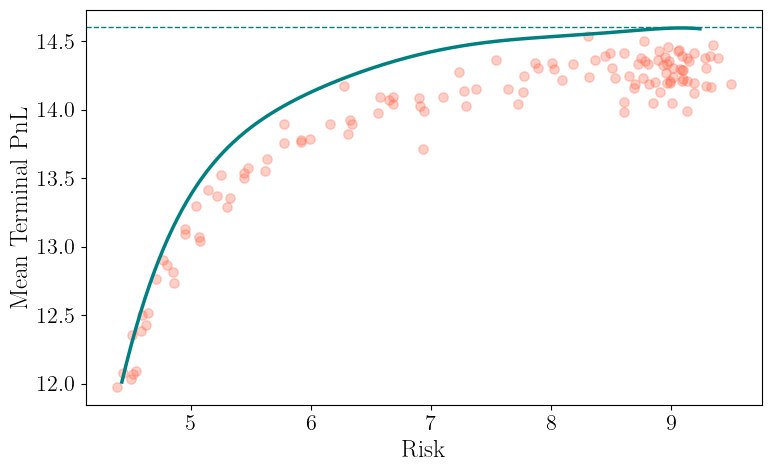

In [80]:
risk = np.sqrt(var_pnl)

# Sort frontier points by risk
idx = np.argsort(risk)
risk_sorted = risk[idx][::2][:-4]
mean_sorted = mean_pnl[idx][::2][:-4]

# Polynomial smoothing
coeffs = np.polyfit(risk_sorted, mean_sorted, deg=6)
poly = np.poly1d(coeffs)

risk_fine = np.linspace(risk[idx].min(), risk[idx].max()+0.1, 500)
mean_smooth = poly(risk_fine)


plt.figure(figsize=(8, 5))
# plt.plot(np.sqrt(var_pnl), mean_pnl, marker="o", linestyle='', color="teal")
plt.scatter(pert_risk, pert_mean, color="tomato", alpha=0.3, s=45)
plt.plot(risk_fine, mean_smooth, color="teal", linewidth=2.5)
plt.axhline(max_mean_pnl, color="teal", linestyle="--", linewidth=1.0)

plt.xlabel("Risk")
plt.ylabel("Mean Terminal PnL")
# plt.title("Market Maker Efficient Frontier")
plt.tight_layout()
plt.savefig(
    "Plots/ct_efficient_frontier_smooth.pdf",
    dpi=1200,
    bbox_inches="tight",
    pad_inches=0.02,
)
plt.show()

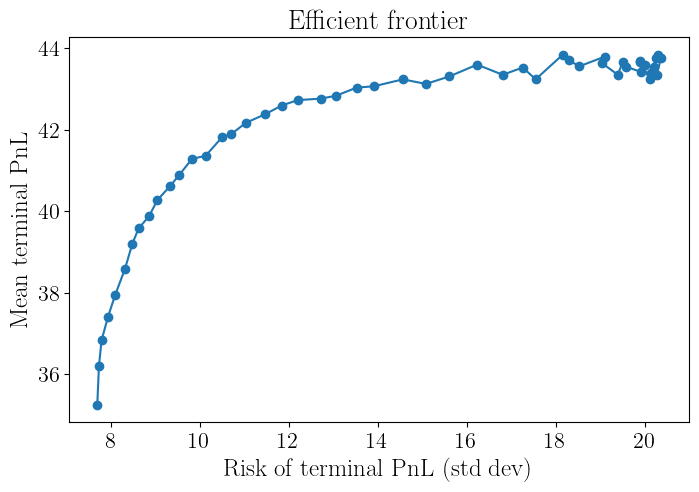

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(np.sqrt(var_pnl), mean_pnl, marker='o')
plt.xlabel("Risk of terminal PnL (std dev)")
plt.ylabel("Mean terminal PnL")
plt.title("Efficient frontier")
plt.show()